## IMPORT

In [430]:
import pandas as pd
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display_html
import numpy as np
from scipy.optimize import curve_fit
import datetime as dt
import plotly.express as px

## PATH

In [431]:
ROOT = Path.cwd().parent

data_path = ROOT / 'data'

## LOAD DATA

In [432]:
df_norm = pd.read_csv(data_path / 'dati_leo_normalizzati.csv').drop(columns=['total'])
df = pd.read_csv(data_path / 'dati_leo_assoluti.csv')
tariffs = pd.read_csv(data_path / 'tariffs_final.csv')

In [433]:
tariffs['Time'] = pd.to_datetime(tariffs['Time']).dt.date

In [434]:
df = df_norm

In [435]:
df = df.drop(columns = ['Europe'])

In [436]:
tariffs.shape, df.shape

((240, 5), (240, 5))

In [437]:
tariffs.columns, df.columns

(Index(['Time', 'China Tariff', 'JP+KR Tariff', 'SoutheastAsia Tariff',
        'Taiwan Tariff'],
       dtype='object'),
 Index(['Time', 'China', 'JP+KR', 'SoutheastAsia', 'Taiwan'], dtype='object'))

In [438]:
[col for col in tariffs.columns if col not in ['Time', col]]

[]

In [439]:
tariffs.loc[:, [col for col in tariffs.columns if col not in ['Time', col]]]

""
0
1
2
3
4
...
235
236
237
238


In [440]:
relative_tariffs = tariffs.copy()
for column in relative_tariffs.columns:
    if column != 'Time':
        relative_tariffs[column] = (1 + tariffs.loc[:, [col for col in tariffs.columns if col not in ['Time', column]]].mean(axis = 1)) / (1 + tariffs[column]) - 1

In [441]:
relative_tariffs_lagged = relative_tariffs.copy()
relative_tariffs_lagged[[col for col in relative_tariffs_lagged.columns if col != 'Time']] = relative_tariffs_lagged[[col for col in relative_tariffs_lagged.columns if col != 'Time']].shift(3).bfill()

In [442]:
relative_tariffs

,Time,China Tariff,JP+KR Tariff,SoutheastAsia Tariff,Taiwan Tariff
0,2002-01-01,0.0,0.0,0.0,0.0
1,2002-02-01,0.0,0.0,0.0,0.0
2,2002-03-01,0.0,0.0,0.0,0.0
3,2002-04-01,0.0,0.0,0.0,0.0
4,2002-05-01,0.0,0.0,0.0,0.0
...,...,...,...,...,...
235,2021-08-01,0.0,0.0,0.0,0.0
236,2021-09-01,0.0,0.0,0.0,0.0
237,2021-10-01,0.0,0.0,0.0,0.0
238,2021-11-01,0.0,0.0,0.0,0.0


## NUOVO

## FUNCTIONS

In [443]:
def compute_utility_functions(df_mk):
    """
    Compute utility from market share data
    """
    ft = np.log(df_mk).subtract(np.log(1-df_mk.sum(1)), axis=0)
    return ft

def polynomial_model(X, a, b, c, d, tau):

    t, tariffs = X
    return a + b * t + c * t ** 2 + d * t ** 3 + tau * tariffs * t

def polynomial_model_no_tariff(X, a, b, c, d, tau):

    t, tariffs = X
    return a + b * t + c * t ** 2 + d * t ** 3

def xtreme_polynomial_model(X, a, b, c, d, e, f, g, tau):
    """
    Degree-7 polynomial model with tariff interaction.
    
    Utility(t, tariff) = a + b*t + c*t^2 + d*t^3 + e*t^4 + f*t^5 + g*t^6 + h*t^7 - tau * tariff * t
    """
    t, tariff = X
    return (a + b * t + c * t**2 + d * t**3 +
            e * t**4 + f * t**5 + g * t**6 +
            tau * tariff * t)

def xtreme_polynomial_model2(X, a, b, c, d, tau0, tau1): 
    t, tariff = X
    return (a + b * t + c * t**2 + d * t**3 + (tau0 + tau1 * t) * tariff)


def xtreme_polynomial_model_no_tariff(X, a, b, c, d, e, f, g, tau):
    """
    Degree-7 polynomial model with tariff interaction.
    
    Utility(t, tariff) = a + b*t + c*t^2 + d*t^3 + e*t^4 + f*t^5 + g*t^6 + h*t^7 - tau * tariff * t
    """
    t, tariff = X
    return (a + b * t + c * t**2 + d * t**3 +
            e * t**4 + f * t**5 + g * t**6)



def polynomial_model_with_seasonality(X, a, b, c, d, tau, tau_s, A, B, e):
    """
    Adds seasonal component: A * sin(2πt/period) + B * cos(2πt/period)
    Default period=12 for monthly seasonality (e.g., 1 year)
    """
    period = 48
    t, tariffs = X
    seasonal = A * np.sin(2 * np.pi * t / period) + B * np.cos(2 * np.pi * t / period)
    return a + b * t + c * t**2 + d * t**3 + tau * tariffs * t + seasonal + e * seasonal * tau_s * tariffs

def polynomial_model_with_seasonality_no_tariff(X, a, b, c, d, tau, A, B):
    """
    Adds seasonal component: A * sin(2πt/period) + B * cos(2πt/period)
    Default period=12 for monthly seasonality (e.g., 1 year)
    """
    period=48
    t, tariffs = X
    seasonal = A * np.sin(2 * np.pi * t / period) + B * np.cos(2 * np.pi * t / period)
    return a + b * t + c * t**2 + d * t**3 + seasonal

from scipy.interpolate import UnivariateSpline

def make_spline_model(t_vals, utility_vals, smoothing=0.5):
    """
    Fit a smooth spline to time series utility data.
    
    Parameters:
        t_vals: array-like, time points
        utility_vals: array-like, utility values at those times
        smoothing: float, smoothing factor (higher = smoother)
        
    Returns:
        spline_model: function X -> spline(t), ignoring tariffs
    """
    spline = UnivariateSpline(t_vals, utility_vals, s=smoothing)

    def spline_model(X, a=None, b=None, c=None, d=None, tau=None):
        t, tariffs = X
        return spline(t)  # tariffs are ignored for now, included for compatibility

    return spline_model



## DERIVATIVES

In [444]:
def xtreme_polynomial_derivative(t, tariff, params):
    """
    Compute dU/dt for xtreme_polynomial_model.

    Parameters:
        t: float or array-like, time
        tariff: float or array-like, tariff at time t
        params: list or array of parameters [a, b, c, d, e, f, g, tau]

    Returns:
        dU/dt evaluated at t
    """
    a, b, c, d, e, f, g, tau = params
    return (b + 2 * c * t + 3 * d * t**2 +
            4 * e * t**3 + 5 * f * t**4 + 6 * g * t**5 -
            tau * tariff)

def polynomial_derivative(t, tariff, params):
    return params[1] + 2 * params[2] * t  + tariff * params[-1]

def polynomial_no_tariff_derivative(t, tariff, params):
    return params[1] + 2 * params[2] * t

def xtreme_polynomial_model2_derivative(t, tariff, params):
    """
    Computes dU/dt analytically.
    
    dU/dt = b + 2c*t + 3d*t^2 + tau1 * tariff
    """
    a, b, c, d, e, tau1 = params
    return b + 2 * c * t + 3 * d * t**2 + tau1 * tariff

def xtreme_polynomial_model_no_tariff_derivative(t, tariff, params):
    a, b, c, d, e, f, g, tariffs = params
    return b + 2 * c * t + 3 * d * t**2 + 4 * e * t**3 + 5 * f * t**4 + 6 * g * t**5

def derivative_polynomial_model_with_seasonality(t, tariff, params):
    """
    Analytical derivative of the polynomial_model_with_seasonality with respect to time t.
    """
    period = 48
    omega = 2 * np.pi / period
    a, b, c, d, tau, tau_s, A, B, e = params

    # Polynomial derivative terms
    poly_derivative = b + 2 * c * t + 3 * d * t**2 + tau * tariff

    # Derivative of seasonal component
    seasonal_derivative = A * omega * np.cos(omega * t) - B * omega * np.sin(omega * t)

    # Derivative of the seasonal interaction term
    e_term_derivative = e * tau_s * tariff * seasonal_derivative

    return poly_derivative + seasonal_derivative + e_term_derivative



In [445]:
pol_func = xtreme_polynomial_model2
tariff_df = tariffs.copy()
derivative = xtreme_polynomial_model2_derivative

In [446]:
utility = compute_utility_functions(df[[c for c in df.columns if c!="Time"]])
# utility.index = df['Time'] # non va bene usare data, serve int
utility.index = range(1, len(utility) + 1)
species = utility.columns.tolist()

In [447]:
px.scatter(utility)

In [448]:

# Fit polynomial models to market share data
head = 0
params_China, _ = curve_fit(pol_func, [utility.index[head:].values, tariff_df['China Tariff'][head:].values], utility['China'][head:])
params_JP_KR, _ = curve_fit(pol_func, [utility.index[head:].values, tariff_df['JP+KR Tariff'][head:].values], utility['JP+KR'][head:])
params_SoutheastAsia, _ = curve_fit(pol_func, [utility.index[head:].values, tariff_df['SoutheastAsia Tariff'][head:].values], utility['SoutheastAsia'][head:])
params_Taiwan, _ = curve_fit(pol_func, [utility.index[head:].values, tariff_df['Taiwan Tariff'][head:].values], utility['Taiwan'][head:])
params_outside, _ = curve_fit(pol_func, [utility.index[head:].values, tariff_df['Taiwan Tariff'][head:].values], utility['Taiwan'][head:])

# Generate predicted values
years_fit = np.linspace(utility.index[:].min(), utility.index[:].max(), 240)

# fitted curves points
utility_fit = pd.DataFrame(np.transpose([
                            pol_func([years_fit, tariff_df['China Tariff']], *params_China),
                            pol_func([years_fit, tariff_df['JP+KR Tariff']], *params_JP_KR),
                            pol_func([years_fit, tariff_df['SoutheastAsia Tariff']], *params_SoutheastAsia),
                            pol_func([years_fit, tariff_df['Taiwan Tariff']], *params_Taiwan),
                            # polynomial_model(years_fit, *params_outside),
                            ]),
                           index=np.linspace(utility.index.min(),utility.index.max(),len(years_fit)),
                           columns = utility.columns
                          )

In [449]:
import plotly.graph_objects as go
import datetime as dt

def plot_market_shares(tariffs, utility, utility_fit, species):
    # Define custom colors in the same order as species
    colors = ['#DE2910',   # China
              '#BC002D',   # JP+KR
              '#F9A602',   # Southeast Asia
              '#000095',   # Taiwan
              '#808080']   # Others

    fig = go.Figure()

    for i, s in enumerate(species):
        # Scatter points (market share data)
        fig.add_trace(go.Scatter(
            x=tariffs['Time'],
            y=utility[s],
            mode='markers',
            name=f'{s} (data)',
            marker=dict(color=colors[i], size=4),
            showlegend=True  # Only show line in legend
        ))
        # Fitted line
        fig.add_trace(go.Scatter(
            x=tariffs['Time'],
            y=utility_fit[s],
            mode='lines',
            name=s,
            line=dict(color=colors[i])
        ))

    # Vertical lines
    for date in [dt.date(2012, 8, 1), dt.date(2015, 1, 1), dt.date(2018, 2, 1)]:
        fig.add_vline(x=date, line_dash="dash", line_color="gray")

    # Update layout
    fig.update_layout(
        title='Market Share Utility Over Time',
        xaxis_title='Date',
        yaxis_title='Utility',
        template='plotly_white',
        width=800,
        height=350,
        legend_title='Species',
        hovermode='x unified'
    )

    fig.show()

plot_market_shares(tariffs, utility, utility_fit, species)

In [450]:
relative_tariffs

,Time,China Tariff,JP+KR Tariff,SoutheastAsia Tariff,Taiwan Tariff
0,2002-01-01,0.0,0.0,0.0,0.0
1,2002-02-01,0.0,0.0,0.0,0.0
2,2002-03-01,0.0,0.0,0.0,0.0
3,2002-04-01,0.0,0.0,0.0,0.0
4,2002-05-01,0.0,0.0,0.0,0.0
...,...,...,...,...,...
235,2021-08-01,0.0,0.0,0.0,0.0
236,2021-09-01,0.0,0.0,0.0,0.0
237,2021-10-01,0.0,0.0,0.0,0.0
238,2021-11-01,0.0,0.0,0.0,0.0


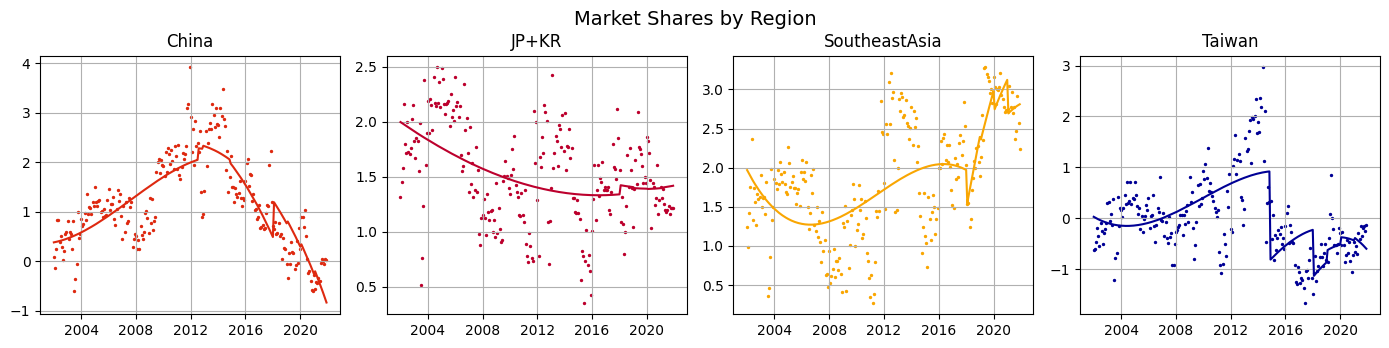

In [451]:
# Set up
fig, axes = plt.subplots(nrows=1, ncols=len(species), figsize=(14, 3.5), sharex=True)
colors = ['#DE2910', '#BC002D', '#F9A602', '#000095', '#808080']  # Color for each species

# Plot each region in its own subplot
for i, s in enumerate(species):
    ax = axes[i]
    ax.scatter(tariffs['Time'], utility[s], color=colors[i], s=2)
    ax.plot(tariffs['Time'], utility_fit[s], color=colors[i])
    ax.set_title(s)
    ax.grid(True)

# General formatting
fig.suptitle('Market Shares by Region', fontsize=14)
fig.tight_layout()
plt.subplots_adjust(top=0.85)  # leave space for suptitle


## UTILITY PROJECTION

In [452]:
# Generate predicted values
years_fit_extended = np.linspace(utility.index[:].min(), utility.index[:].max() + 240, 480)

new_tariffs = tariff_df.copy()
new_tariffs[[spec + ' Tariff' for spec in species]] = 0
new_tariffs['China Tariff'] = 0

new_tariff_df = pd.concat([tariff_df.copy(), new_tariffs], axis = 0).reset_index(drop=True)

# fitted curves points
utility_fit_extended = pd.DataFrame(np.transpose([
                            pol_func([years_fit_extended, new_tariff_df['China Tariff']], *params_China),
                            pol_func([years_fit_extended, new_tariff_df['JP+KR Tariff']], *params_JP_KR),
                            pol_func([years_fit_extended, new_tariff_df['SoutheastAsia Tariff']], *params_SoutheastAsia),
                            pol_func([years_fit_extended, new_tariff_df['Taiwan Tariff']], *params_Taiwan),
                            # polynomial_model(years_fit, *params_outside),
                            ]),
                           index=years_fit_extended,
                           columns = utility.columns
                          )

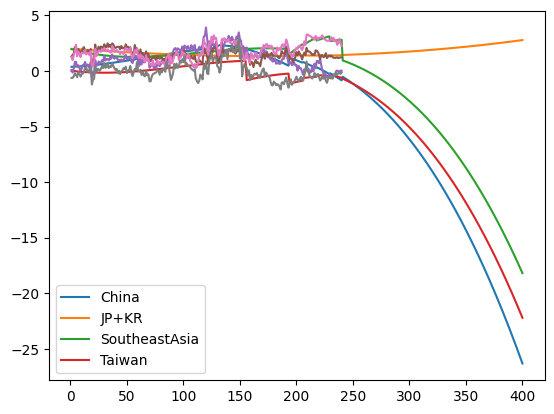

In [453]:
utility_fit_extended.loc[:400, :].plot()
plt.plot(utility)

## LV MODEL

In [454]:

def LV_market_share_4species(t, SPECIES, params_x, params_y, params_z, params_w, tariffs):
    """
    Lotka–Volterra system for 4 species with utility-driven growth.

    Parameters:
        t: time (float or int)
        SPECIES: list or array of market shares [X, Y, Z, W]
        params_x/y/z/w: parameters for each region's utility function
        tariffs: list of tariffs [tariff_x, tariff_y, tariff_z, tariff_w] at time t

    Returns:
        dX_dt, dY_dt, dZ_dt, dW_dt
    """
    X, Y, Z, W = SPECIES
    
    print(t)

    tariff_x, tariff_y, tariff_z, tariff_w = tariffs.loc[int(t), :]

    print(tariff_x)

    gx = derivative(t, tariff_x, params_x)
    gy = derivative(t, tariff_y, params_y)
    gz = derivative(t, tariff_z, params_z)
    gw = derivative(t, tariff_w, params_w)

    total_interaction = gx * X + gy * Y + gz * Z + gw * W

    dX_dt = X * (gx - total_interaction)
    dY_dt = Y * (gy - total_interaction)
    dZ_dt = Z * (gz - total_interaction)
    dW_dt = W * (gw - total_interaction)

    return dX_dt, dY_dt, dZ_dt, dW_dt


In [455]:
species = utility.columns.to_list()
species

['China', 'JP+KR', 'SoutheastAsia', 'Taiwan']

In [456]:
# Initial conditions
y0 = df[species].iloc[0].tolist()

# Time span
t_span = ((df.index).min(), (df.index).max())
t_eval = (df.index).tolist()

# Solve ODE system with the time-dependent derivative function
X, Y, Z, W = solve_ivp(LV_market_share_4species, t_span, y0, t_eval=t_eval, args=(params_China,params_JP_KR,params_SoutheastAsia, params_Taiwan, tariff_df.drop(columns = 'Time'))).y

0.0
0.0
0.8302609818898047
0.0
0.04848165448414988
0.0
0.07272248172622481
0.0
0.19392661793659952
0.0
0.215474019929555
0.0
0.2424082724207494
0.0
0.2424082724207494
0.0
0.7272248172622482
0.0
0.9696330896829974
0.0
2.1816744517867446
0.0
2.3971484717162994
0.0
2.666490996628243
0.0
2.666490996628243
0.0
7.514656445043231
0.0
9.938739169250724
0.0
22.0591527902882
0.0
24.213892989583744
0.0
26.907318238703184
0.0
26.907318238703184
0.0
40.46577949660612
0.0
47.245010125557585
0.0
81.1411632703149
0.0
87.1671460516051
0.0
94.69962452821784
0.0
94.69962452821784
0.0
111.65851951655665
0.0
120.13796701072604
0.0
162.5352044815731
0.9055
170.072491143057
0.9055
179.49409946991187
0.9055
179.49409946991187
0.9055
102.51312464297938
0.0
106.41987470036014
0.0
125.95362498726398
0.0
129.42629170493578
0.3463
133.76712510202552
0.4651
133.76712510202552
0.4651
99.8160985867208
0.0
102.37433561597227
0.0
115.16552076222965
0.0
117.4395092326754
0.0
120.2819948207326
0.0
120.2819948207326
0.0
1

In [457]:
t_eval[0]

0

In [458]:
derivative(t_eval[0], 1, params_China)

np.float64(-0.024700649225736553)

In [459]:
import plotly.graph_objects as go

def plot_market_share_vs_model(t_eval, df, X, Y, Z, W):
    # Improved color palette
    colors = ['#1f77b4',  # blue
              '#d62728',  # red
              '#2ca02c',  # green
              '#9467bd']  # purple

    labels = ['China', 'JP+KR', 'SoutheastAsia', 'Taiwan']
    model_vars = [X, Y, Z, W]

    fig = go.Figure()

    # Plot market share data as dots
    for i, label in enumerate(labels):
        fig.add_trace(go.Scatter(
            x=t_eval,
            y=df[label],
            mode='markers',
            name=f'{label} (data)',
            marker=dict(color=colors[i], size=5, symbol='circle')
        ))

    # Plot L-V model results as lines
    for i, label in enumerate(labels):
        fig.add_trace(go.Scatter(
            x=t_eval,
            y=model_vars[i],
            mode='lines',
            name=f'{label} (model)',
            line=dict(color=colors[i])
        ))

    # Update layout
    fig.update_layout(
        title='Market Share Data vs Lotka–Volterra Model',
        xaxis_title='Time',
        yaxis_title='Market Share',
        template='plotly_white',
        width=800,
        height=350,
        legend_title='Legend',
        hovermode='x unified'
    )

    fig.show()


In [460]:
plot_market_share_vs_model(t_eval, df, X, Y, Z, W)

## PREDICTION

In [461]:
tariff_df

,Time,China Tariff,JP+KR Tariff,SoutheastAsia Tariff,Taiwan Tariff
0,2002-01-01,0.00,0.00,0.00,0.00
1,2002-02-01,0.00,0.00,0.00,0.00
2,2002-03-01,0.00,0.00,0.00,0.00
3,2002-04-01,0.00,0.00,0.00,0.00
4,2002-05-01,0.00,0.00,0.00,0.00
...,...,...,...,...,...
235,2021-08-01,0.15,0.15,0.15,0.15
236,2021-09-01,0.15,0.15,0.15,0.15
237,2021-10-01,0.15,0.15,0.15,0.15
238,2021-11-01,0.15,0.15,0.15,0.15


In [466]:
# Initial conditions
y0 = df[species].iloc[0].tolist()

# Time span
t_span = (0, 360)
t_eval = np.linspace(0, 360, 360)

tariff_hyp = tariff_df.copy()[:129]
tariff_hyp[[spec + ' Tariff' for spec in species]] = 0
tariff_hyp['SoutheastAsia Tariff'] = 1

tariff_df_pred = pd.concat([tariff_df.copy(), tariff_hyp], axis = 0).reset_index(drop=True)

# Solve ODE system with the time-dependent derivative function
X, Y, Z, W = solve_ivp(LV_market_share_4species, t_span, y0, t_eval=t_eval, args=(params_China,params_JP_KR,params_SoutheastAsia, params_Taiwan, tariff_df_pred.drop(columns = 'Time'))).y

0.0
0.0
0.8302609818898047
0.0
0.04848165448414988
0.0
0.07272248172622481
0.0
0.19392661793659952
0.0
0.215474019929555
0.0
0.2424082724207494
0.0
0.2424082724207494
0.0
0.7272248172622482
0.0
0.9696330896829974
0.0
2.1816744517867446
0.0
2.3971484717162994
0.0
2.666490996628243
0.0
2.666490996628243
0.0
7.514656445043231
0.0
9.938739169250724
0.0
22.0591527902882
0.0
24.213892989583744
0.0
26.907318238703184
0.0
26.907318238703184
0.0
40.46577949660612
0.0
47.245010125557585
0.0
81.1411632703149
0.0
87.1671460516051
0.0
94.69962452821784
0.0
94.69962452821784
0.0
111.65851951655665
0.0
120.13796701072604
0.0
162.5352044815731
0.9055
170.072491143057
0.9055
179.49409946991187
0.9055
179.49409946991187
0.9055
102.51312464297938
0.0
106.41987470036014
0.0
125.95362498726398
0.0
129.42629170493578
0.3463
133.76712510202552
0.4651
133.76712510202552
0.4651
99.8160985867208
0.0
102.37433561597227
0.0
115.16552076222965
0.0
117.4395092326754
0.0
120.2819948207326
0.0
120.2819948207326
0.0
1

In [467]:
tariff_hyp

,Time,China Tariff,JP+KR Tariff,SoutheastAsia Tariff,Taiwan Tariff
0,2002-01-01,0,0,1,0
1,2002-02-01,0,0,1,0
2,2002-03-01,0,0,1,0
3,2002-04-01,0,0,1,0
4,2002-05-01,0,0,1,0
...,...,...,...,...,...
124,2012-05-01,0,0,1,0
125,2012-06-01,0,0,1,0
126,2012-07-01,0,0,1,0
127,2012-08-01,0,0,1,0


In [468]:
tariff_df_pred

,Time,China Tariff,JP+KR Tariff,SoutheastAsia Tariff,Taiwan Tariff
0,2002-01-01,0.0,0.0,0.0,0.0
1,2002-02-01,0.0,0.0,0.0,0.0
2,2002-03-01,0.0,0.0,0.0,0.0
3,2002-04-01,0.0,0.0,0.0,0.0
4,2002-05-01,0.0,0.0,0.0,0.0
...,...,...,...,...,...
364,2012-05-01,0.0,0.0,1.0,0.0
365,2012-06-01,0.0,0.0,1.0,0.0
366,2012-07-01,0.0,0.0,1.0,0.0
367,2012-08-01,0.0,0.0,1.0,0.0


In [469]:
plot_market_share_vs_model(t_eval, df, X, Y, Z, W)